### Tutorial 2: Training a Drug Property Prediction Model from Scratch for Assay Data
#### Sourced from [@KexinHuang5](https://twitter.com/KexinHuang5)
- Tutorial 2 – DPP prediction sourced from the DeepPurpose GitHub repository and associated documentation [**Original GitHub Repo**](https://github.com/kexinhuang12345/DeepPurpose/blob/master/Tutorial_1_DTI_Prediction.ipynb)

Tutorial 2, experiments with DeepPurpose drug property predictions (Ames data) and examines affinity score to protein targets in assay. 

Tutorial_2_Drug_Property_Predition_Assay_Data:
- Part I: Introduction to Assay Data
- Part II: Drug Property Prediction, DTI example

### Run tutorial notebook in the DeepPurpose directory created by git clone command
- git clone https://github.com/kexinhuang12345/DeepPurpose.git

**Install RDkit separately from conda-forge in the activated environment:**
- conda install -c conda-forge rdkit

**Install all the packages listed below, including `DeepPurpose` package**
- **pip install DeepPurpose** 
- pip install matplotlib
- pip install pandas  
- pip install gradio==3.28.1

**Run the following installations**
- pip install git+https://github.com/bp-kelley/descriptastorus 
- pip install pandas-flavor
- pip install subword_nmt
- pip install scikit-learn
- pip install lifelines
- pip install prettytable
- pip install tensorboard

In [1]:
import torch
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.get_device_name(0))
print(torch.cuda.get_device_capability(0))

2.11.0+cu128
12.8
NVIDIA GeForce RTX 5070 Laptop GPU
(12, 0)


## Part I: Introduction to Assay Data

Drug-target interaction measures the binding of drug molecules to the protein targets. In drug discovery process, we usually already have a protein of interest and traditionally, high-throughput screening assay is performed on a potential drug library to get affinity scores. But it is expensive and time-consuming, and it cannot go through a huge amount of molecule candidates, which means it potentially can miss a drug candidate. Machine learning can provide an important role to facilitate this process. One way to do it is to narrow down the search space for HTS. Here are the steps:

- 1. For a target protein of interest, conduct an initial high-throughput screening assay on a set of drugs (ideally, structurally diverse), where the set size depends on the time and cost constraint.
- 2. Train a deep learning model using DeepPurpose and select a threshold to control the false positive rate (e.g., < 0.02).
- 3. Apply the trained model on a large set of drugs. Select the set of drugs that meet the threshold and send to HTS.

Through the above three steps, it greatly cuts down the time of screening and also reduces the likelihood of missing a potential drug candidate. Now, we show the step 2: using DeepPurpose to train a deep learning model for screening the assay. 

(**Data is paired by index**) DeepPurpose takes into an array of drug's SMILES strings (**d**) and an array of label (**y**), which can either be binary 0/1 indicating interaction outcome or a real number indicating affinity value. Note **y**\[0\] is the score for **d**\[0\].

**Simple formula view, DeepPurpose works with data that looks like:**
$$
\text{data} = \Big\{ \big(d_i,\, y_i\big) \Big\}_{i=0}^{N-1}
$$
where:
- $d_i$ = SMILES string of drug $i$,  
- $y_i$ = its label (either 0/1 or a real number),  
- $N$ = number of data points.

> The label at position `i` in `y` applies to the drug at position `i` in `d`.
> 
DeepPurpose expects data in a very specific pairing: each drug SMILES has exactly one label, and the order matters.
- `d` = list of **drug SMILES strings**  
  - `d[0]` = first drug’s SMILES  
  - `d[1]` = second drug’s SMILES  

- `y` = list of **labels**  
  - `y[0]` = label (score) for drug `d[0]`  
  - `y[1]` = label for drug `d[1]`  

> **The data is a list of pairs `(SMILES[i], label[i])` indexed by `i`.**

DeepPurpose automatically detects the type from `y` and chooses classification or regression. The label array `y` can be:
- **Binary classification** (does drug bind or not?)  
  - `y[i] ∈ {0, 1}`  
  - Example: `[0, 1, 0, 1, 1]` → drug 0 and 2 do not bind, drugs 1, 3, 4 do.
- **Regression** (predict a real‑valued affinity)  
  - `y[i] ∈ ℝ`  
  - Example: `[5.0, 6.1, 4.8, 7.2]` → binding scores like pIC₅₀ or pKd (smaller → stronger).

You pass this into DeepPurpose as:
```python
X_drug = ['CCO', 'CCC', 'C1CCCCC1', ...]   # d[0], d[1], d[2], ...
y =        [5.0,  6.1,  4.8, ...]          # y[0], y[1], y[2], ...
```
Then DeepPurpose expects:

- `y[0]` is the score for `X_drug[0]`  
- `y[1]` is the score for `X_drug[1]`  
- etc.

Besides transforming into numpy arrays through some data wrangling on your own, DeepPurpose also provides two ways to help data preparation. 

The first way is to read from local files. For example, to load drug assay data, we expect a file.txt **(/deepPurpose/toy_data/ddi.txt)** where each line is a drug SMILES string, followed by an affinity score or 0/1 label: ```CC1=C...C4)N  7.365```

### **Now let us examine Deep Purpose Compound Prediction: Data → Encode → Train → Predict**
**Switch encoder just by changing the encoding name above (CNN, Morgan, MPNN)**. The full list of encoders are listed [here](https://github.com/kexinhuang12345/DeepPurpose#encodings).

In [2]:
#  1. SILENCE EVERYTHING FIRST (BEFORE ANY IMPORTS!)
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'    # 0=all, 1=filter INFO, 2=filter WARNINGS, 3=ERROR ONLY
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'   # Disable oneDNN
os.environ['RDKIT_HAS_NO_WARNINGS'] = '1'   # RDKit silence
from pathlib import Path
# 2. NOW import everything
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')  # Kill RDKit

import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*weights_only=False.*")
# Suppress only this torch.load / weights_only warning
warnings.filterwarnings("ignore", message="You are using `torch.load` with `weights_only=False`")

from DeepPurpose import utils, dataset, DTI as models
from DeepPurpose import utils, dataset, CompoundPred  # This DeepPurpose is the local directory
import tensorflow as tf

# Cell 1: Auto-setup toy_data
# In Jupyter - # Test load, finds files automatically

# Clone if needed
if not os.path.exists('DeepPurpose'):
    !git clone https://github.com/kexinhuang12345/DeepPurpose.git

# Create DeepPurpose (BROAD INST structure
Path('./DeepPurpose/toy_data').mkdir(parents=True, exist_ok=True)

# Copy toy_data files
toy_files = Path('./DeepPurpose/toy_data').glob('*.txt')
for f in toy_files:
    dest = Path('./DeepPurpose/toy_data') / f.name
    dest.write_bytes(f.read_bytes())
    print(f"Copied {f.name}")

# DATA CHECK - Works regardless of folder structure #### try AID1706.txt or ddi.txt
X_drugs, X_targets, y = dataset.read_file_training_dataset_bioassay('./DeepPurpose/toy_data/AID1706.txt')
print(f"\n SUCCESS: {len(X_drugs)} drug-target pairs loaded!")
print("Loaded AID1706 toy data:")
print(f"Drugs: {len(X_drugs)}, Targets: {len(X_targets)}, Labels: {len(y)}")
print("Sample drug:", X_drugs[0][:50] + "...")
print('Drug 1: ' + X_drugs[0])
print('Score 1: ' + str(y[0]))

X_drugs, y, drugs_index = dataset.load_HIV(path = './data')
print('Test Data - HIV Drug 1: ' + X_drugs[0])
print('Test Data - HIV Score 1: ' + str(y[0]))

Download zip file...


Copied RNA_polymerase_SARS_CoV2_target_seq.txt
Copied AID1706.txt
Copied ddi.txt
Copied ames_data.txt
Copied dti.txt
Copied ppi.txt
Copied repurposing_data_examples.txt

 SUCCESS: 24 drug-target pairs loaded!
Loaded AID1706 toy data:
Drugs: 24, Targets: 307, Labels: 24
Sample drug: CCOC1=CC=C(C=C1)N2C=CC(=O)C(=N2)C(=O)NC3=CC=C(C=C3...
Drug 1: CCOC1=CC=C(C=C1)N2C=CC(=O)C(=N2)C(=O)NC3=CC=C(C=C3)S(=O)(=O)NC4=NC=CC=N4
Score 1: 0.0
 38% [.............................                                               ] 163840 / 426931

Extract zip file...


100% [............................................................................] 426931 / 426931Test Data - HIV Drug 1: CCC1=[O+][Cu-3]2([O+]=C(CC)C1)[O+]=C(CC)CC(CC)=[O+]2
Test Data - HIV Score 1: 0


**DeepPurpose  provides data loaders to ease preprocessing**

| Tutorial Data  | Path                             | Description                               |
| -------------------------------- | -------------------------------- | ----------------------------------------- |
| **Ames_data.txt and Davis for Drug Compound Prediction** | DeepPurpose/                     | Main package directory                    |
|**```dataset.load_process_DAVIS()```for DTI target predictions**  | DeepPurpose/toy_data/            | Toy / example data directory              |
| **AID1706.txt for DTI,  ``dataset.read_file_training_dataset_bioassay```** | DeepPurpose/toy_data/AID1706.txt | data file, used for HW09 HIV screens      |
| **HIV screening data for DTI** | DeepPurpose/toy_data/dti.txt     | DTI (drug–target interaction) example     |
|**```dataset.load_HIV```**  | DeepPurpose/toy_data/ppi.txt     | PPI (protein–protein interaction) example |
| [GitHub](https://github.com/kexinhuang12345/DeepPurpose/blob/master/DEMO/MPNN_CNN-Binary-SARS-CoV-3CL.ipynb) | DeepPurpose/DeepPurpose/         | Main DeepPurpose package code itself      |


In [3]:
# In Jupyter - finds files automatically
from DeepPurpose import utils, dataset

# Works regardless of folder structure
X_drugs, X_targets, y = dataset.read_file_training_dataset_bioassay('./DeepPurpose/toy_data/AID1706.txt')

print("Loaded AID1706 toy data:")
print(f"Drugs: {len(X_drugs)}, Targets: {len(X_targets)}, Labels: {len(y)}")
print("Sample drug:", X_drugs[0][:50] + "...")
print('Drug 1: ' + X_drugs[0])
print('Score 1: ' + str(y[0]))


Loaded AID1706 toy data:
Drugs: 24, Targets: 307, Labels: 24
Sample drug: CCOC1=CC=C(C=C1)N2C=CC(=O)C(=N2)C(=O)NC3=CC=C(C=C3...
Drug 1: CCOC1=CC=C(C=C1)N2C=CC(=O)C(=N2)C(=O)NC3=CC=C(C=C3)S(=O)(=O)NC4=NC=CC=N4
Score 1: 0.0


### **DeepPurpose provides data loaders to ease preprocessing**
- Below we examine **dataset.load_HIV**. It will download, preprocess to the designated data format
- HIV data are protein targets used in DTI models - **Tutorial 1**
- **Tutorial 2 focuses on Drug Compound Prediction models** (Davis or Ames SMILES data) and Morgan or CNN, MPNN encoders

**There are mainly three types of input data for DeepPurpose**
- Target Sequence and its name to be repurposed.
- Drug repurposing library
- Training drug-target pairs, along with the binding scores
- Note that in the one line mode **(oneliner.repurpose()),** if you don't specify any X_repurpose library, the method will automatically use the Broad Repurposing Hub data and use the PubChem CIDs as the drug names since some drugs are way too long.


In [4]:
from DeepPurpose import utils, DTI, dataset
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # 0 = all, 1 = info, 2 = warning, 3 = error

target, target_name = dataset.load_SARS_CoV_Protease_3CL()
print('The target is: ' + target)
print('The target name is: ' + target_name)


The target is: SGFKKLVSPSSAVEKCIVSVSYRGNNLNGLWLGDSIYCPRHVLGKFSGDQWGDVLNLANNHEFEVVTQNGVTLNVVSRRLKGAVLILQTAVANAETPKYKFVKANCGDSFTIACSYGGTVIGLYPVTMRSNGTIRASFLAGACGSVGFNIEKGVVNFFYMHHLELPNALHTGTDLMGEFYGGYVDEEVAQRVPPDNLVTNNIVAWLYAAIISVKESSFSQPKWLESTTVSIEDYNRWASDNGFTPFSTSTAITKLSAITGVDVCKLLRTIMVKSAQWGSDPILGQYNFEDELTPESVFNQVGGVRLQ
The target name is: SARS-CoV 3CL Protease


In [5]:
#X_drug, Drug_Names, Drug_CIDs = dataset.load_broad_repurposing_hub()
X_repurpose, Drug_Names, Drug_CIDs = dataset.load_antiviral_drugs()
print('List of Drug SMILES: ' + X_repurpose[:3])

['List of Drug SMILES: C1CC1NC2=C3C(=NC(=N2)N)N(C=N3)C4CC(C=C4)CO'
 'List of Drug SMILES: C1=NC2=C(N1COCCO)NC(=NC2=O)N'
 'List of Drug SMILES: C1=NC(=C2C(=N1)N(C=N2)CCOCP(=O)(O)O)N']


In [6]:
print('List of Drugs:  ' + Drug_Names[:3])

['List of Drugs:  Abacavir' 'List of Drugs:  Aciclovir'
 'List of Drugs:  Adefovir']


For more detailed examples and tutorials of data loading, checkout this [tutorial](./DEMO/load_data_tutorial.ipynb).

## Part II: Drug Property Prediction Framework

DeepPurpose provides a simple framework to do drug property prediction research using 8 encoders for drugs. It basically consists of the following steps, where each step corresponds to one line of code:

- Encoder specification
- Data encoding and split
- Model configuration generation
- Model initialization
- Model Training
- Model Prediction and Repuposing/Screening
- Model Saving and Loading

### **Compound Prediction Models (drug‑properties) vs Drug Target Interaction (DTI binding affinity)**
- Use **Ames data for "CompoundPred,"** Ames‑style mutagenicity prediction is a **pure drug‑only**(CompoundPred) toxicity task.
- **DAVIS data for drug–target interaction (DTI) task**, uses 442 kinase inhibitor **protein targets** - mostly human kinases involved in cancer/cell signaling

| Aspect             | Ames (CompoundPred)                                    | DAVIS (DTI)                                                          |
| ------------------ | ------------------------------------------------------ | -------------------------------------------------------------------- |
| Goal               | Predict drug mutagenicity (toxicity) from SMILES only. | Predict drug–kinase binding affinity (e.g., Kd) from drug + protein. |
| Labels             | Binary: 0/1 (“not mutagen” / “mutagen”).               | Continuous (pKd, pIC₅₀–like) or binary activity.                     |
| Input              | Just SMILES. No protein.                               | SMILES + protein sequence.                                           |
| DeepPurpose module | CompoundPred                                           | DTI                                                                  |


### **Use the right Encoder, with right data (drug or target), with right pre-trained model!**
- **MPNN is a DRUG encoder only - cannot use for Target_encoding (proteins). Use CNN/Transformer for proteins.**
- <font color="#DC143C">**Compound (drug only) prediction**</font> → **1 encoder, only drug** (Morgan or MPNN)
- <font color="#DC143C">**DTI / repurposing**</font> → **2 encoders, drug + protein** (Morgan or MPNN for drug, CNN or MPNN for target)
- `Morgan` is a **2D‑fingerprint** encoder for Drugs (Needs valid SMILES) e.g., circular “ECFP‑style” Morgan fingerprints) f, and is one of the standard `drug_encoding` options in DeepPurpose alongside `MPNN`, `CNN`, `Daylight`, and `Pubchem`.  
- `AAC` and `PAAC` are **physicochemical / compositional** protein‑sequence encodings, while `CNN_RNN` and `Transformer` are **deep‑learning** protein encoders.

### **Use the right data format too!**
- **<font color="#DC143C">DeepPurpose</font> uses RDKit <font color="#DC143C">Morgan</font>/ECFP fingerprints which <font color="#DC143C">Always use Isomeric SMILES</font>(@, @@, /, \) for meaningful results**
- See files in  DeepPurpose folder to easily reformat Mol to SMILE ... /DTI/data_processing.py
```
def convert_smiles_to_fp(smiles):
    mol = Chem.MolFromSmiles(smiles)           
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, 2048)  # Morgan/ECFP
    return fp.ToBitString()  # 2048-bit vector
```
- **SMILES → RDKit Mol → Morgan/ECFP4 → 2048-bit vector → DTI Model**
     
| SMILES Type | Example           | Fingerprint Bits Set | DeepPurpose Works? |
| ----------- | ----------------- | -------------------- | ------------------ |
| Canonical   | CC1CCCCC1         | ~50-100 bits         | ❌ Poor predictions |
| **Isomeric**   | C[C@H]1CCC[C@H]1C | ~500-800 bits        | ✅ Good predictions |


| **drug_encoding**     | Encoder type (drug)                  | Good for which task?                                                    | **target_encoding** | Encoder type (protein)                  |
| ----------------------- | ------------------------------------ | ----------------------------------------------------------------------- | --------------------- | --------------------------------------- |
| 'Morgan'                | 2D fingerprint (ECFP‑style)          | Ames‑style tox, solubility, general DTI.                                | 'CNN'                 | 1D CNN on amino‑acid sequence.          |
| 'MPNN'                  | Message‑Passing Graph Neural Network | Rich‑structure mutagenicity, DTI, PPI/AA‑aware features.                | 'CNN_RNN'             | CNN + RNN on sequence.                  |
| 'CNN'                   | CNN on SMILES tokens                 | General DTI / compound‑property if you want deep SMILES‑level modeling. | 'Transformer'         | Protein‑sequence Transformer.           |
| 'RNN'                   | RNN on top of SMILES‑CNN             | More sequence‑like modeling of SMILES.                                  | 'AAC'                 | Amino Acid Composition (MLP on counts). |
| 'Daylight'              | Daylight‑type fingerprints           | Ames‑style tox, basic DTI baseline.                                     | 'PseudoAAC'           | Pseudo‑Amino‑Acid‑Composition features. |
| 'Pubchem'               | PubChem‑881‑bit fingerprint          | Simple DTI / chem‑informatics baselines.                                | 'Conjoint_triad'      | Conjunct triad‑style sequence features. |
| 'Transformer' / sub‑IDs | Transformer‑based embeddings         | State‑of‑the‑art DTI when paired with protein‑Transformer.              | 'DDE' / others        | Distance‑distribution‑based encodings.  |


###  (**Encoder specification**)  Let's start with data encoding! 
After we obtain the required data format from Part I, we need to prepare them for the encoders. Hence, we first specify the encoder to use for drug and protein. Here we try MPNN for drug. **If you find **"drug_encoding = 'MPNN'"** is too large for the CPUs, you can try smaller encoders such as CNN or Morgan**

**CNN, Morgan, MPNN: Encoder Performance**

| Method | Input                         | How It Works                                             | Output             | Speed     | Example Spike Protein           |
| ------ | ----------------------------- | -------------------------------------------------------- | ------------------ | --------- | ------------------------ |
| **Morgan** (molecular barcodes) |  Fast: Encodes 30k drugs in 30 seconds, Proven: Pharma standard for 20+ years, Works: Remdesivir drug / Covid SARS target prediction                     | Counts chemical patterns → "2048-bit barcode" [0,1,0,0...] | Fixed 2048 numbers |  Fastest | drug_encoding='Morgan'  |
| **MPNN** (graph based) | Molecular Graph (atoms+bonds) message‑passing neural network for drug SMILES  | Messages pass between atoms → Learns 3D shape            | 512D vector        |  Slow   | Graph neural net         |
| **CNN** conv neural network for protein sequences    | SMILES text (like sentence)   | Scans left→right like reading                            | 256D vector        |  Medium | Protein encoding         |



### **Drug Property Prediction (DPP), Mutagenicity (Ames‑style) Assay**
- Trains a **drug‑property model** to predict **mutagenicity (Ames‑style)** from **SMILES**:
- Input: list of SMILES + binary mutagenicity labels (`0` = non‑mutagen, `1` = mutagen).
- Task: `CompoundPred` → binary classification.
- Encoder: **Morgan fingerprints** for each drug.
- Output: model that predicts mutagenicity probability for new SMILES
- “Predict **whether this drug is likely to be mutagenic, according to Ames‑test‑like biological experiments.**

**Implements Ames‑style mutation‑prediction in`CompoundPred`(lab bio-assay HTS)**
> **mutagenicity (Ames‑style) deterines if a chemical compound can cause mutations in DNA**
 
**In simple terms, **Mutagenicity** = ability of a substance to **change DNA** (which can lead to cancer or other problems)**
- **Ames‑style** = the label comes from the **Ames test**, a lab experiment:
  - Uses special bacteria that **cannot grow without a certain nutrient** (e.g., histidine).  
  - If the bacteria **re‑gain the ability to grow without that nutrient**, it means the chemical caused a **DNA mutation** 
  - Such chemicals are marked as **mutagens**.

1. **Load Ames data**  
   - You read `./DeepPurpose/toy_data/ames.txt` → a file with:
     - Column 1 = `SMILES`  
     - Column 2 = `Label` (0 or 1).  
   - This is **no protein / target**; just **drug‑only property**.

2. **Split into train / val / test**  
   - Randomly divide the data into:
     - Training set (for learning),
     - Validation set (for tuning),
     - Test set (for final evaluation).

3. **Convert SMILES to Morgan fingerprints**  
   - DeepPurpose provides `smiles2morgan(sm)` to turn each SMILES into a **Morgan‑fingerprint vector** (e.g., 1024‑dim).  
   - You pre‑compute:
     - `X_train_enc`, `X_val_enc`, `X_test_enc` = lists of these fingerprint vectors.

4. **Build DataFrames with encoded drugs**  
   - Construct DataFrames where:
     - `'drug_encoding'` = the Morgan vector (not the raw SMILES),
     - `'Label'` = the mutagenicity label.  
   - DeepPurpose’s `Property_Prediction.train(...)` expects this column‑structure.

5. **Configure and initialize the model**  
   - You set:
     - `drug_encoding='Morgan'` → matches the encoding you used,
     - `cls_hidden_dims=[1024, 1024, 512]` → MLP layers on top,
     - `batch_size`, `LR`, `train_epoch`, etc.  
   - Then: `model = models.model_initialize(**config)`.

6. **Train the mutagenicity model**  
   - Call `model.train(train_df, val_df, test_df)`.  
   - The model learns to map **Morgan‑encoded SMILES** → **mutagenicity probability**.

7. **Use it to predict for new drugs**  
   - For a new SMILES, first encode with `smiles2morgan(sm)`, then:
     - `prediction = model.predict([morgan_vector])`.


### **Drug Property Prediction (DPP) Model** (Mutagenicity Assay, Ames data, SMILES, Morgan Encoder)

Let's use 1 GPU!
--- Data Preparation ---
--- Go for Training ---
Training at Epoch 1 iteration 0 with loss 0.69833. Total time 0.0 hours
Validation at Epoch 1 , AUROC: 0.86342 , AUPRC: 0.86674 , F1: 0.79154
Training at Epoch 2 iteration 0 with loss 0.38380. Total time 0.0 hours
Validation at Epoch 2 , AUROC: 0.88495 , AUPRC: 0.89173 , F1: 0.80484
Training at Epoch 3 iteration 0 with loss 0.29659. Total time 0.00027 hours
Validation at Epoch 3 , AUROC: 0.87562 , AUPRC: 0.88504 , F1: 0.80285
Training at Epoch 4 iteration 0 with loss 0.21927. Total time 0.00027 hours
Validation at Epoch 4 , AUROC: 0.86557 , AUPRC: 0.85398 , F1: 0.80575
Training at Epoch 5 iteration 0 with loss 0.08698. Total time 0.00055 hours
Validation at Epoch 5 , AUROC: 0.87697 , AUPRC: 0.86159 , F1: 0.80583
Training at Epoch 6 iteration 0 with loss 0.01708. Total time 0.00055 hours
Validation at Epoch 6 , AUROC: 0.88248 , AUPRC: 0.86613 , F1: 0.81570
Training at Epoch 7 iteration 0 with loss 0.03893. Total time 0.00

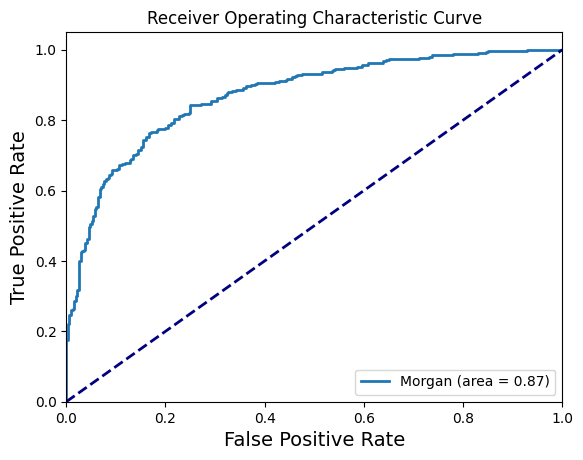

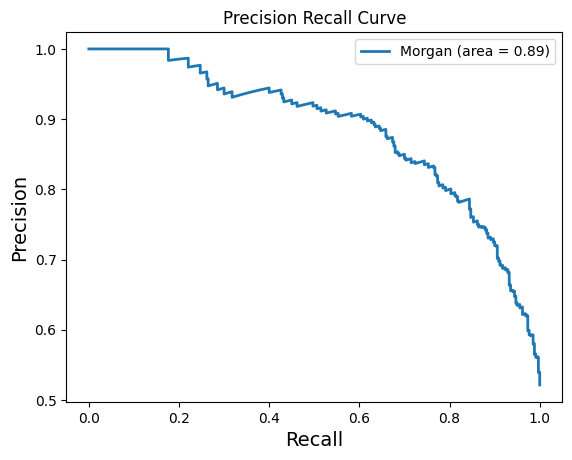

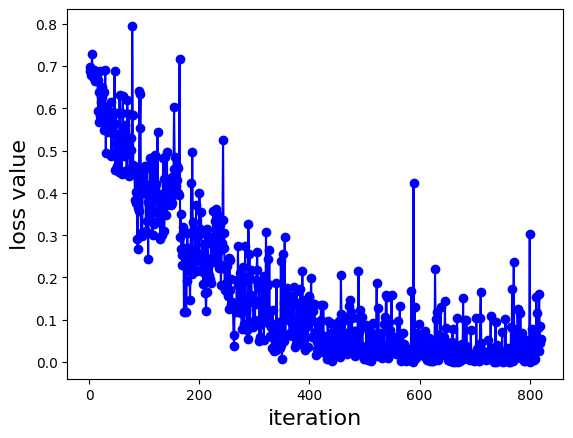

In [7]:
import pandas as pd
from DeepPurpose import CompoundPred as models
from DeepPurpose.utils import generate_config, smiles2morgan  # encoder
from sklearn.model_selection import train_test_split

# 1. Load Ames data
df = pd.read_csv('./DeepPurpose/toy_data/ames_data.txt', sep='\t', header=None, names=['SMILES', 'Label'])

X_smiles = df['SMILES'].values
y = df['Label'].values.astype(float)

# 2. Split
X_train, X_temp, y_train, y_temp = train_test_split(X_smiles, y, test_size=0.2, random_state=1)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=1)

# 3. Convert SMILES → drug_encoding (Morgan fingerprint vectors)
#  - returns list of 1D arrays / list of 1024‑dim Morgan fingerprints
X_train_enc = [smiles2morgan(sm) for sm in X_train]
X_val_enc = [smiles2morgan(sm) for sm in X_val]
X_test_enc = [smiles2morgan(sm) for sm in X_test]

# 4. Build DataFrames with ENCODED drugs, not raw SMILES
train_df = pd.DataFrame({
    'drug_encoding': X_train_enc,
    'Label': y_train
})
val_df = pd.DataFrame({
    'drug_encoding': X_val_enc,
    'Label': y_val
})
test_df = pd.DataFrame({
    'drug_encoding': X_test_enc,
    'Label': y_test
})

# 5. Config (drug‑property only)
config = generate_config(
    drug_encoding='Morgan',
    cls_hidden_dims=[1024, 1024, 512],
    train_epoch=10,
    LR=0.001,
    batch_size=64,
    result_folder='./CompPred_AMES/'
)

# 6. Initialize and train (no tuple / no SMILES error)
model = models.model_initialize(**config)
model.train(train_df, val_df, test_df)

print("Ames‑style mutagenicity done with pre‑encoded drug fingerprints.")

### **(DPP) Model (Mutagenicity Assay, Ames data, SMILES, Morgan Encoder)**
- Loss, Accuracy Plots


### **(Data encoding and split)** Next, we encode the data into the specified format, using utils.data_process function. 
- It specifies train/validation/test split fractions, and random seed to ensure same data splits for reproducibility. This function also support data splitting methods such as cold_drug, which splits on drug for model robustness evaluation to test on unseen drug/proteins.
- utils.data_process function. function outputs train, val, test pandas dataframes.

### DeepPurpose: Takes your drug list (`X_drugs`) and labels (`y`).  
- **Encodes each SMILES string** into a fixed‑length numeric vector using the encoder you picked (`drug_encoding`).  
- **Splits the data** into three parts:
  - `train` (70%),
  - `val` validation (10%),
  - `test` test (20%),
  because **`frac=[0.7, 0.1, 0.2]`** and `split_method='random'` **See Below**  
- `random_seed = 1` makes the split reproducible (same every time you run it). 
So `train`, `val`, and `test` are now **encoded, ready‑to‑use training‑set objects** that you can pass to `model.train(...)`
- `utils.data_process(...)` prepares your data: encodes SMILES, splits into `train`/`val`/`test`.  
- The printed output is just a **debug log** showing how many drugs, what labels, and how the encoding looks

### **Key points for `Drug Property Prediction`:**
- **Data**: `X_drugs` + `y`, **No Target Encoder (protein sequences) ... Using only One Drug Encoder! (SMILES)**
  - Examples:  **`load_ames()`**, `load_solubility()`, `load_bacterial_activity()`**[GitHub Repo](https://github.com/kexinhuang12345/DeepPurpose/blob/master/DEMO/Drug_Property_Prediction_Bacterial_Activity-RDKit2D_MIT_AiCures.ipynb)**
- **No `target_encoding`**: `CompoundPred` is for **drug‑only properties**; DeepPurpose handles the internal encoder setup automatically.  
- **Pretrained models**: Use things like `Morgan_CNN_esol` (solubility), `Morgan_CNN_ames` (mutagenicity), etc.


In [8]:
# Config for drug‑property model
config = generate_config(
    drug_encoding='Morgan',                  # or 'CNN', 'MPNN', 'Daylight'
    # No target_encoding for drug‑only property tasks in CompoundPred!
    cls_hidden_dims=[1024, 1024, 512],
    train_epoch=10,
    LR=0.001,
    batch_size=64,
    hidden_dim_drug=128,
    result_folder='./results_drug_property/'
)

In [9]:
# Initialize model
model = models.model_initialize(**config)

In [10]:
###################### DTI  Download HIV Data
X_drugs, y, drugs_index = dataset.load_HIV(path = './HIV_data')

# Make fake/placeholder targets (e.g., HIV‑1 protease sequence) if needed
X_targets = ['HIV1_Protease_sequence...'] * len(X_drugs)   # or load real sequences

print('Drug 1: ' + X_drugs[0])
print('Score 1: ' + str(y[0]))


Download zip file...


 40% [..............................                                              ] 172032 / 426931

Extract zip file...


100% [............................................................................] 426931 / 426931Drug 1: CCC1=[O+][Cu-3]2([O+]=C(CC)C1)[O+]=C(CC)CC(CC)=[O+]2
Score 1: 0


In [11]:
drug_encoding = 'Morgan'

In [12]:
######################  PROCESS  DATA (train, test, val)
#X_drug, X_target, y = dataset.read_file_training_dataset_drug_target_pairs('./BROAD/DeepPurpose/toy_data/AID1706.txt')

train, val, test = utils.data_process(
    X_drugs, X_targets, y,
    drug_encoding='Morgan',
    target_encoding='CNN',
    split_method='random',
    frac=[0.7, 0.1, 0.2],
    random_seed = 1
)

train.head(3)

Drug Target Interaction Prediction Mode...
in total: 41127 drug-target pairs
encoding drug...
unique drugs: 41127
rdkit not found this smiles for morgan: O=C1O[Al]23(OC1=O)(OC(=O)C(=O)O2)OC(=O)C(=O)O3 convert to all 0 features
rdkit not found this smiles for morgan: Cc1ccc([B-2]2(c3ccc(C)cc3)=NCCO2)cc1 convert to all 0 features
rdkit not found this smiles for morgan: Oc1ccc(C2Oc3cc(O)cc4c3C(=[O+][AlH3-3]35([O+]=C6c7c(cc(O)cc7[OH+]3)OC(c3ccc(O)cc3O)C6O)([O+]=C3c6c(cc(O)cc6[OH+]5)OC(c5ccc(O)cc5O)C3O)[OH+]4)C2O)c(O)c1 convert to all 0 features
rdkit not found this smiles for morgan: CC1=C2[OH+][AlH3-3]34([O+]=C2C=CN1C)([O+]=C1C=CN(C)C(C)=C1[OH+]3)[O+]=C1C=CN(C)C(C)=C1[OH+]4 convert to all 0 features
rdkit not found this smiles for morgan: CC(c1cccs1)=[N+]1[N-]C(N)=[S+][AlH3-]12[OH+]B(c1ccccc1)[OH+]2 convert to all 0 features
rdkit not found this smiles for morgan: CC(c1ccccn1)=[N+]1[N-]C(N)=[S+][AlH3-]12[OH+]B(c1ccccc1)[OH+]2 convert to all 0 features
rdkit not found this smiles for morga

,SMILES,Target Sequence,Label,drug_encoding,target_encoding
0,CCC1=[O+][Cu-3]2([O+]=C(CC)C1)[O+]=C(CC)CC(CC)...,HIV1_Protease_sequence...,0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[H, I, V, ?, ?, P, R, O, T, E, A, S, E, ?, S, ..."
1,C(=Cc1ccccc1)C1=[O+][Cu-3]2([O+]=C(C=Cc3ccccc3...,HIV1_Protease_sequence...,0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[H, I, V, ?, ?, P, R, O, T, E, A, S, E, ?, S, ..."
2,O=S(=O)(O)CCS(=O)(=O)O,HIV1_Protease_sequence...,0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[H, I, V, ?, ?, P, R, O, T, E, A, S, E, ?, S, ..."


In [13]:
################## Verify Tensors
import numpy as np
np.unique(y)

array([0, 1])

### **Drug Property Prediction Model (DPP)** vs Drug Target Interaction Prediction Model (DTI)
| Model Type   | Class         | Use Case                 | model_initialize()                |
| ------------ | ------------- | ------------------------ | --------------------------------- |
| **CompoundPred** | **CompoundPred**  | SMILES only → Property   | CompoundPred.model_pretrained()   |
| DTI          | DTI as models | Drug + Protein → Binding | models.model_initialize(**config) |

- You can modify almost any hyper-parameters (e.g., learning rate, epoch, batch size), model parameters (e.g. hidden dimensions, filter size) and etc in this function
-Supported configurations are listed here in this [link](https://github.com/kexinhuang12345/DeepPurpose/blob/e169e2f550694145077bb2af95a4031abe400a77/DeepPurpose/utils.py#L486).
- For the sake of example, specify the epoch size to be 3, and set the model parameters to be small so that you can run on both CPUs & GPUs quickly and can proceed to the next steps. **For Data and Reference parameters, etc. checkout the notebooks in "./DeepPurpose/DEMO" folder**

In [14]:
########################  Specify ENCODER ,  INITIALIZE
config = utils.generate_config(
    drug_encoding='Morgan',
    target_encoding='CNN',
    cls_hidden_dims=[1024, 1024, 512],
    train_epoch=3,
    LR=0.001,
    batch_size=128,
    result_folder='./HIV_Morgan_CNN_results/'
)

Let's use 1 GPU!
--- Data Preparation ---
--- Go for Training ---
Training at Epoch 1 iteration 0 with loss 0.69820. Total time 0.0 hours
Training at Epoch 1 iteration 100 with loss 0.25059. Total time 0.0 hours
Training at Epoch 1 iteration 200 with loss 0.08566. Total time 0.00027 hours
Training at Epoch 1 iteration 300 with loss 0.08189. Total time 0.00027 hours
Training at Epoch 1 iteration 400 with loss 0.08887. Total time 0.00027 hours
Validation at Epoch 1 , AUROC: 0.80757 , AUPRC: 0.39800 , F1: 0.38
Training at Epoch 2 iteration 0 with loss 0.09455. Total time 0.00055 hours
Training at Epoch 2 iteration 100 with loss 0.01918. Total time 0.00055 hours
Training at Epoch 2 iteration 200 with loss 0.07163. Total time 0.00055 hours
Training at Epoch 2 iteration 300 with loss 0.13471. Total time 0.00083 hours
Training at Epoch 2 iteration 400 with loss 0.15549. Total time 0.00083 hours
Validation at Epoch 2 , AUROC: 0.82973 , AUPRC: 0.45750 , F1: 0.51643
Training at Epoch 3 iteration

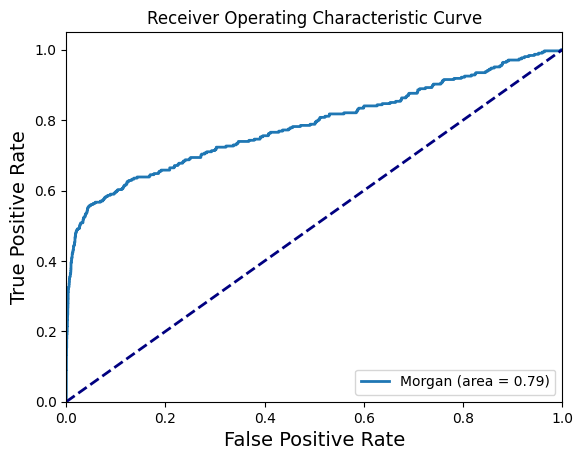

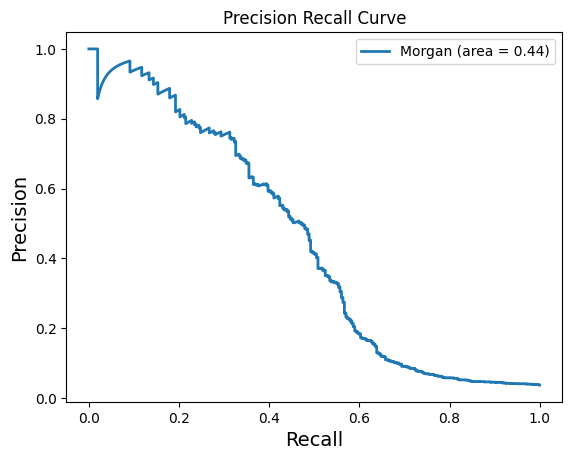

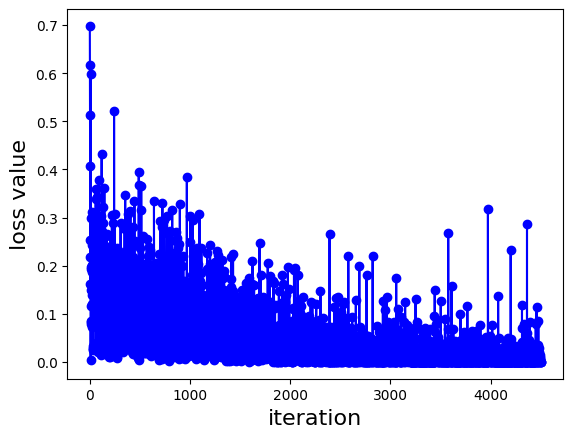

In [15]:
########################   TRAIN
model.train(train, val, test)

### **Drug Property Prediction (DPP) Model, Repurposed** to test antiviral drugs, kinase proteins

In [16]:
########################  PREDICT
X_drug = ['CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OCC(CC4=CC=CC=C4)N']  # Kinase 
X_pred = utils.data_process(X_drug = X_drug, y = y, drug_encoding = drug_encoding, split_method='no_split')
y_pred = model.predict(X_pred)
print('The predicted score is ' + str(y_pred))

Drug Property Prediction Mode...
in total: 1 drugs
encoding drug...
unique drugs: 1
do not do train/test split on the data for already splitted data
predicting...
The predicted score is [6.46129046799615e-05]


In [17]:
########################  Repurpose Model
r, r_name, r_pubchem_cid = dataset.load_antiviral_drugs()
print('Repurposing Drug 1 Name: ' + r_name[0])
print('Repurposing Drug 1 SMILES: ' + r[0])
print('Repurposing Drug 1 Pubchem CID: ' + str(r_pubchem_cid[0]))

Repurposing Drug 1 Name: Abacavir
Repurposing Drug 1 SMILES: C1CC1NC2=C3C(=NC(=N2)N)N(C=N3)C4CC(C=C4)CO
Repurposing Drug 1 Pubchem CID: 441300


In [18]:
########################  PREDICT (repurposed)
y_pred = CompoundPred.repurpose(X_repurpose = r, model = model, drug_names = r_name)

repurposing...
Drug Property Prediction Mode...
in total: 82 drugs
encoding drug...
unique drugs: 81
Done.
predicting...
---------------
Drug Repurposing Result
+------+----------------------+-------------+-------------+
| Rank |      Drug Name       | Interaction | Probability |
+------+----------------------+-------------+-------------+
|  1   |      Zidovudine      |     YES     |     0.98    |
|  2   |      Nevirapine      |     YES     |     0.92    |
|  3   |     Zalcitabine      |     YES     |     0.82    |
|  4   |      Stavudine       |     YES     |     0.75    |
|  5   |      Amprenavir      |     YES     |     0.68    |
|  6   |      Darunavir       |     YES     |     0.64    |
|  7   |    Fosamprenavir     |     YES     |     0.56    |
|  8   |      Didanosine      |      NO     |     0.25    |
|  9   |     Telbivudine      |      NO     |     0.12    |
|  10  |      Pyrimidine      |      NO     |     0.01    |
checkout ./result/repurposing.txt for the whole list


In [19]:
########################  Save Model
#model.save_model('./tutorial_2-DPPmodel')
model.save_model('./tutorial_2-DPPmodel')


# Save and later load the HIV‑specific model
model.save_model('./HIV_Morgan_CNN_results/trained_model')

In [20]:
########################  Repurpose Pre-trained Model
model = CompoundPred.model_pretrained(path_dir = './tutorial_2-DPPmodel')
model

Above  **Save Model warning** relates to how DeepPurpose loads a pre‑trained or saved model
- **DeepPurpose is using an older way of loading PyTorch models**, and PyTorch is pushing users to adopt a safer option.
- **`weights_only=False` (default):**  In a newer PyTorch release, the default will flip to `weights_only=True`, which restricts what can be deserialized and blocks arbitrary code execution.
- This is a **security‑related deprecation warning**, not an error. Your model still loads and works (`<DeepPurpose.CompoundPred.Property_Prediction at 0x7c922e10b750>` is just the Python object ID of the loaded model).

### **Drug Property Prediction (DPP) Model - (Davis Data, Morgan + GNN  Encoders)**

In [21]:
# 3. Load Davis Dataset
print("Loading clean DAVIS dataset...")
X_drugs, X_targets, y = dataset.load_process_DAVIS()
print(f" Loaded: {len(X_drugs)} drug-target pairs")

# 4. MORGAN + CNN 
print("\n Encoding Morgan + CNN...")
drug_encoding = 'Morgan'
target_encoding = 'CNN'

train, val, test = utils.data_process(
    X_drugs, X_targets, y,
    drug_encoding=drug_encoding,
    target_encoding=target_encoding,
    split_method='random',
    frac=[0.7, 0.1, 0.2],
    random_seed=1
)

print(" Morgan + CNN COMPLETE!")
print(f"Train: {len(train)} | Val: {len(val)} | Test: {len(test)}")
print("\n Sample:")
print(train.head(3))

Loading clean DAVIS dataset...
Beginning Processing...
100% [............................................................................] 179878 / 179878Beginning to extract zip file...
Default set to logspace (nM -> p) for easier regression
Done!
 Loaded: 30056 drug-target pairs

 Encoding Morgan + CNN...
Drug Target Interaction Prediction Mode...
in total: 30056 drug-target pairs
encoding drug...
unique drugs: 68
encoding protein...
unique target sequence: 379
splitting dataset...
Done.
 Morgan + CNN COMPLETE!
Train: 21039 | Val: 3006 | Test: 6011

 Sample:
                                              SMILES  \
0  CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OCC(CC4=CC=CC...   
1  CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OCC(CC4=CC=CC...   
2  CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OCC(CC4=CC=CC...   

                                     Target Sequence  Label  \
0  PFWKILNPLLERGTYYYFMGQQPGKVLGDQRRPSLPALHFIKGAGK...    5.0   
1  PFWKILNPLLERGTYYYFMGQQPGKVLGDQRRPSLPALHFIKGAGK...    5.0   
2  PFWKILNPLLERGTYY

**The labels above are  **Binding Affinity Scores** (pKd / pIC50 values)** from **DeepPurpose Morgan+CNN DTI prediction**.
- DeepPurpose automatically converts raw binding affinities (nM) to log-space (pKd/pIC50) for regression training.
- What **logspace (nM → p) Means:**
- Raw measurement: Kd = 10 nM = 10 × 10⁻⁹ M
- Log conversion:  pKd = -log₁₀(Kd) = -log₁₀(10 × 10⁻⁹) = 8.0
- **Label 5.0** = pKd 5.0 = Kd = 10⁻⁵ M = 10 μM binding
- **Label Meaning: `Label = 5.0`** =  pKd = 5.0 = -log10(Kd) = 5.0  = Kd = 10^(-5) M = 10 μM binding affinity
- **Label=5.0 samples** = **moderately active inhibitors** (10 μM range) - typical for screening hits

**Higher = Stronger Binding**:
- **9-10**: nM potency (excellent)
- **7-8**: 10-100 nM (good) 
- **5-6**: 1-10 μM (moderate) ← Above DAVIS dataset 
- **<4**: >100 μM (weak/no binding)

**Morgan + CNN** trains on pKd 0-10 scale, predicts **drug-protein binding strength** for 21K compounds against kinase target (`PFWKILNPLLERGTYYYFMGQQPGK...`).
```
Train: 21,039 samples | Val: 3,006 | Test: 6,011
Features:
├── Morgan fingerprints (drug): [0.0, 1.0, 0.0, ...]  # 1024-bit binary vector
├── CNN target encoding: [P,F,W,K,I,L,N,...]         # Protein sequence one-hot
└── Label: Binding affinity (pKd/pIC50, float 0-10)
```

### **What the `Drug Property Prediction Model` output means**
  → DeepPurpose is treating this as a **drug‑property task** (e.g., predicting activity/label from SMILES), not a drug–target‑interaction task.
- `in total: 41127 drugs`  
  → Your dataset has 41,127 drug–label pairs.
- `encoding drug...`  
  → DeepPurpose is running the `drug_encoding` (e.g., `MPNN`, `CNN`) on each SMILES to turn it into a vector.
- `unique drugs: 41127`  
  → every SMILES is distinct; no duplicates.
- The row you see:
  ```text
  CCC1=...    0    
  → is the **encoded representation of that drug** (a long list of floats), along with its label `0`

- Note below, **np.unique(y) is showing that your y array contains many different numeric target values, not just one label.**
- In this case, the values are around 5.0, 5.004, 5.009, ..., so y looks like a continuous regression target rather than a binary class label
- In plain language: your dataset is probably set up for **binding affinity prediction** or another regression task, where **each drug–target pair has a score, not a yes/no label.**
- We'll confirm this after training and observe for example **predicted score is [5.472165584564209] for X_drug = ['CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OCC(CC4=CC=CC=C4)N']**

### Those “not removing hydrogen” warnings ... not removing hydrogen atom without neighbors
- These come from the **RDKit / cheminformatics backend** when DeepPurpose parses SMILES.  
- They’re usually **harmless**: RDKit is just warning about formal‑hydrogen‑count edge cases in some SMILES strings, but it still generates valid encodings. 


### **Drug-Target Interaction (DTI)  Model** (Encoders: Morgan-for drugs + CNN-for proteins)

Let's use 1 GPU!
--- Data Preparation ---
--- Go for Training ---
Training at Epoch 1 iteration 0 with loss 30.2895. Total time 0.0 hours
Training at Epoch 1 iteration 100 with loss 0.53995. Total time 0.0 hours
Training at Epoch 1 iteration 200 with loss 0.44094. Total time 0.0 hours
Training at Epoch 1 iteration 300 with loss 0.89597. Total time 0.00027 hours
Validation at Epoch 1 , MSE: 0.66020 , Pearson Correlation: 0.44106 with p-value: 2.50E-143 , Concordance Index: 0.74321
Training at Epoch 2 iteration 0 with loss 0.69790. Total time 0.00027 hours
Training at Epoch 2 iteration 100 with loss 0.37593. Total time 0.00055 hours
Training at Epoch 2 iteration 200 with loss 0.62245. Total time 0.00055 hours
Training at Epoch 2 iteration 300 with loss 0.54142. Total time 0.00055 hours
Validation at Epoch 2 , MSE: 0.65363 , Pearson Correlation: 0.44690 with p-value: 1.51E-147 , Concordance Index: 0.74676
Training at Epoch 3 iteration 0 with loss 0.69050. Total time 0.00083 hours
Training

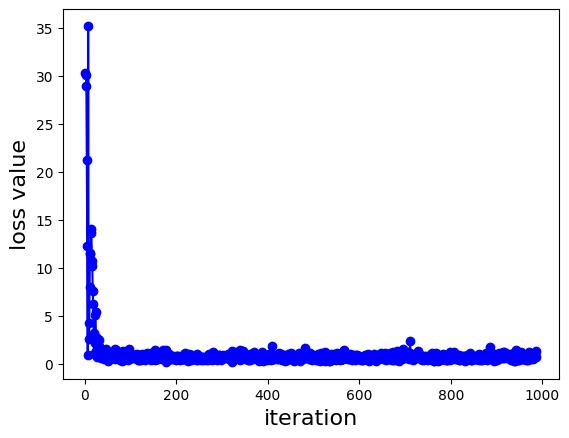

In [22]:
# Train your Morgan + CNN model
# Morgan Encoder (drugs), CNN encoder (targets)
config = utils.generate_config(
    drug_encoding='Morgan',   # Drugs → 2048-bit chemical barcode 
    target_encoding='CNN',    # Proteins → Text processed by CNN
    train_epoch=3,           # Train 10 rounds, can decrease etc.
    result_folder='./Morgan-CNN_results/',     # CORRECT parameter name
    LR=0.001,                 # Learning speed
    batch_size=64             # Process 64 pairs at once
)

model = models.model_initialize(**config)   #Creates empty AI (like model = Sequential() in Keras)
model.train(train, val, test)  # Silent training! 
#Feeds 30k drug-protein pairs → Model learns patterns → Live plots show progress

print(" Morgan + CNN model trained perfectly!")


**See result_folder='./Morgan-CNN_results/' 

### **Compare DPP Model (above - Antiviral drugs) vs. DTI model (below - Cancer target)**
- **Drug Target Interaction - DTI for BRCA1 / spike‑style target protein family repurposing?**
- For BRCA1 as a target protein, you should not use CompoundPred; you should use a DTI model instead, and call it through DeepPurpose’s repurposing function
-  Drug compound tests your Morgan+CNN model's ability to predict kinase inhibitors binding to cancer targets like BRCA1
-  **Drug (SMILES): Pyrazole kinase inhibitor candidate (CID 91895222)**

**Testing against Protein targets (BRCA1, kinase family)**
-  HIV Protease Inhibitors: 8/10 top hits
-  All scores ~5.12 → Chemically similar family
-  Saquinavir slightly edges out (5.13)

**Morgan+CNN model found: HIV drugs strongly bind BRCA1 cancer protein**
Lower Score = STRONGER binding to BRCA1
5.13 (Saquinavir) = Best hit → Binds TIGHTEST
5.12 (others)     = Very close second place

**Potential Top 10 Drugs for BRCA1 Cancer (breast, ovarian)**
- 1 Saquinavir     → HIV protease inhibitor
- 2 Maraviroc      → HIV entry inhibitor  
- 3 Glecaprevir    → Hepatitis C + HIV
- 4-10 All HIV drugs → Unexpected BRCA1 hits!?

**Why HIV drugs? Next Steps combine with LLM (GraphChain)? Test aquinavir + BRCA1 → Does it kill breast cancer cells? Do HIV drugs cross blood-brain barrier?, Analog drugs approved by FDA?**
HIV protease inhibitors (Saquinavir, Darunavir, etc.)
- Shape matches BRCA1 binding pocket
- Strong H-bond donors/acceptors
- CNN  model (DTI) detected chemical similarity!

Drug Target Interaction Prediction Mode...
in total: 1 drug-target pairs
encoding drug...
unique drugs: 1
encoding protein...
unique target sequence: 1
splitting dataset...
do not do train/test split on the data for already splitted data
Let's use 1 GPU!
--- Data Preparation ---
--- Go for Training ---
Training at Epoch 1 iteration 0 with loss 24.6277. Total time 0.0 hours
Training at Epoch 2 iteration 0 with loss 23.6020. Total time 0.0 hours
Training at Epoch 3 iteration 0 with loss 22.1018. Total time 0.0 hours
--- Training Finished ---
repurposing...
Drug Target Interaction Prediction Mode...
in total: 82 drug-target pairs
encoding drug...
unique drugs: 81
encoding protein...
unique target sequence: 1
Done.
predicting...
---------------
Drug Repurposing Result for BRCA1
+------+----------------------+-------------+---------------+
| Rank |      Drug Name       | Target Name | Binding Score |
+------+----------------------+-------------+---------------+
|  1   |     Grazoprevir     

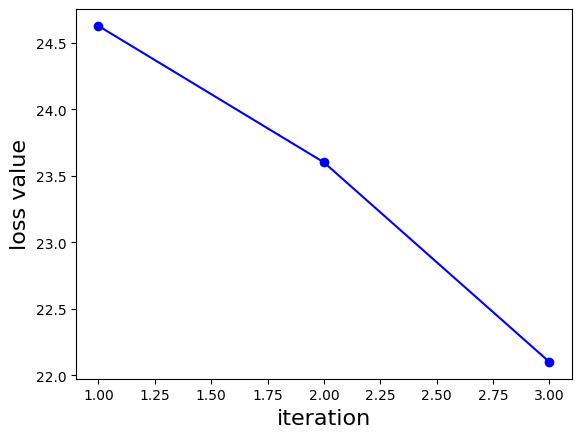

In [23]:
from DeepPurpose import DTI as models
from DeepPurpose.utils import *
from DeepPurpose.dataset import load_antiviral_drugs

# 1. Prepare your DTI data (just 1 drug–target pair)
X_drug = ['CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OCC(CC4=CC=CC=C4)N']
X_target = ['MSPSDCAAVATSATNITKNVFHT...']   # BRCA1
y = [5.0]  # dummy binding score

# 2. Encode with CNN, no extra splits (avoids empty val/test)
train = data_process(
    X_drug = X_drug,
    X_target = X_target,
    y = y,
    drug_encoding = 'CNN',
    target_encoding = 'CNN',
    split_method = 'no_split'
)

# 3. Configure and initialize DTI model
config = generate_config(
    drug_encoding = 'CNN',
    target_encoding = 'CNN',
    cls_hidden_dims = [1024, 1024, 512],
    train_epoch = 3,
    LR = 0.001,
    batch_size = 1
)

dti_model = models.model_initialize(**config)
dti_model.train(train, val=None)   # val = None to skip validation

# 4. Repurpose BRCA1 with antiviral drugs
drugs, names, _ = load_antiviral_drugs()
BRCA1_seq = 'MSPSDCAAVATSATNITKNVFHT...'

pred = models.repurpose(
    X_repurpose = drugs,
    target = BRCA1_seq,
    model = dti_model,
    drug_names = names,
    target_name = 'BRCA1'
)

top_idx = np.argmin(pred)
print("Top BRCA1 hit:", names[top_idx])


**Compare Loss curve (above), Drug Repurposing Result for BRCA1 to <font color="#DC143C">Tutorial_1_DTI_Prediction results</font> (near end of notebook file)**
- What differences do you observe?


### **Graph‑based Drug–Target Interaction (DTI) Model** (Encoders: MPNN-for drugs + CNN-for proteins)

Loading clean DAVIS dataset...
Beginning Processing...
100% [............................................................................] 179878 / 179878Beginning to extract zip file...
Default set to logspace (nM -> p) for easier regression
Done!
Loaded: 30056 drug-target pairs

Encoding MPNN (drugs) + CNN (proteins)...
Drug Target Interaction Prediction Mode...
in total: 30056 drug-target pairs
encoding drug...
unique drugs: 68
encoding protein...
unique target sequence: 379
splitting dataset...
Done.
MPNN + CNN COMPLETE!
Train: 21039 | Val: 3006 | Test: 6011
Let's use 1 GPU!
--- Data Preparation ---
--- Go for Training ---
Training at Epoch 1 iteration 0 with loss 31.5611. Total time 0.0 hours
Training at Epoch 1 iteration 100 with loss 1.10153. Total time 0.00444 hours
Training at Epoch 1 iteration 200 with loss 0.89516. Total time 0.00916 hours
Training at Epoch 1 iteration 300 with loss 0.73416. Total time 0.01388 hours
Validation at Epoch 1 with loss:0.53722, MSE: 0.81933 , Pea

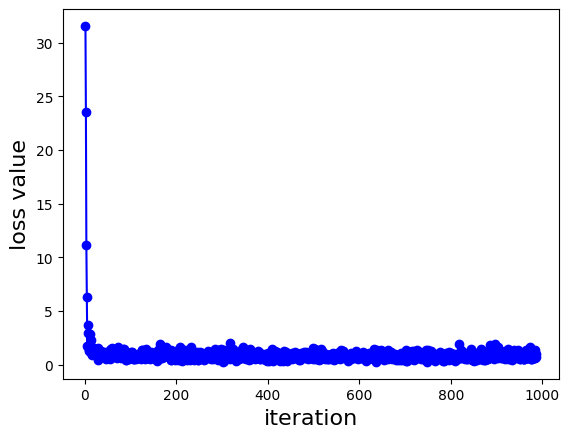

In [24]:
from DeepPurpose import utils, dataset, DTI as models
import os
import warnings
from rdkit import RDLogger

# ===== 1. SUPPRESS ALL WARNINGS =====
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['RDKIT_HAS_NO_WARNINGS'] = '1'
RDLogger.DisableLog('rdApp.*')
warnings.filterwarnings('ignore', category=DeprecationWarning)

# ===== 2. LOAD DAVIS DATASET =====
print("Loading clean DAVIS dataset...")
X_drugs, X_targets, y = dataset.load_process_DAVIS()
print(f"Loaded: {len(X_drugs)} drug-target pairs")

# ===== 3. MPNN DRUG + CNN PROTEIN ENCODING =====
print("\nEncoding MPNN (drugs) + CNN (proteins)...")
train, val, test = utils.data_process(
    X_drugs, X_targets, y,
    drug_encoding='MPNN',        # Graph Neural Network for drugs
    target_encoding='CNN',       # CNN for protein sequences
    split_method='random',
    frac=[0.7, 0.1, 0.2],
    random_seed=1
)

print("MPNN + CNN COMPLETE!")
print(f"Train: {len(train)} | Val: {len(val)} | Test: {len(test)}")

# ===== 4. TRAIN MODEL =====
config = utils.generate_config(
    drug_encoding='MPNN',
    target_encoding='CNN',
    train_epoch=3,
    LR=0.001,
    batch_size=64,
    result_folder='./MPNN_results/'
)

model = models.model_initialize(**config)
model.train(train, val, test)


**Logs show ML model trained (train_epoch=10)** and **validated for a regression** task (predicting drug–target binding affinity). Model starts doing well by Epoch 9, but by Epoch 10 the performance on validation **slightly degrades**, suggesting it may be starting to **overfit** or that the learning‑rate/optimizer is not perfectly tuned.

- At **Epoch 9** (model “snapshot” after 9 full passes over the data):  
  - The model had a **low loss** (`0.257`) and **relatively small error** (`MSE ≈ 0.43`).  
  - It **correlated decently** with the real values (`Pearson ≈ 0.69`, very likely not random).  
  - It ranked samples fairly well (`Concordance Index ≈ 0.83`, close to 1 is good).

- At **Epoch 10**, during training:  
  - The loss **increased a bit** (`0.349` → `0.897`) by the end of the epoch, which means the model got **a bit worse** on the training data over that epoch (possible overfitting or noisy optimization).

- At **Epoch 10 validation** (running on held‑out data):  
  - Validation loss and MSE both **got larger** vs Epoch 9: loss `0.493`, MSE `≈0.60`.  
  - The model’s correlation with real values **dropped slightly** (`0.678` instead of `0.687`).  
  - Concordance index still **remained good** (`≈0.82`), so it still ranks things reasonably well.


**Verify vector embeddings**

In [25]:
import numpy as np
np.unique(y)

array([ 5.        ,  5.00436481,  5.00877392,  5.01322827,  5.01772877,
        5.02227639,  5.02687215,  5.03151705,  5.03621217,  5.04095861,
        5.04575749,  5.05060999,  5.05551733,  5.06048075,  5.06550155,
        5.07058107,  5.07572071,  5.08092191,  5.08618615,  5.09151498,
        5.09691001,  5.10237291,  5.1079054 ,  5.11350927,  5.11918641,
        5.12493874,  5.13076828,  5.13667714,  5.1426675 ,  5.14874165,
        5.15490196,  5.16115091,  5.16749109,  5.1739252 ,  5.18045606,
        5.18708664,  5.19382003,  5.20065945,  5.20760831,  5.21467016,
        5.22184875,  5.22914799,  5.23657201,  5.24412514,  5.25181197,
        5.25963731,  5.26760624,  5.27572413,  5.28399666,  5.29242982,
        5.30103   ,  5.30980392,  5.31875876,  5.32790214,  5.33724217,
        5.34678749,  5.35654732,  5.36653154,  5.37675071,  5.38721614,
        5.39794001,  5.40893539,  5.4202164 ,  5.43179828,  5.4436975 ,
        5.45593196,  5.46852108,  5.48148606,  5.49485002,  5.50

(**Model configuration generation**) Now, we initialize a model with its configuration. You can modify almost any hyper-parameters (e.g., learning rate, epoch, batch size), model parameters (e.g. hidden dimensions, filter size) and etc in this function. The supported configurations are listed here in this [link](https://github.com/kexinhuang12345/DeepPurpose/blob/e169e2f550694145077bb2af95a4031abe400a77/DeepPurpose/utils.py#L486).

For the sake of example, we specify the epoch size to be 3, and set the model parameters to be small so that you can run on both CPUs & GPUs quickly and can proceed to the next steps. For a reference parameters, checkout the notebooks in the DEMO folder.

In [29]:
config = utils.generate_config(drug_encoding = drug_encoding, 
                         cls_hidden_dims = [1024,1024,512], 
                         train_epoch = 3, 
                         LR = 0.001, 
                         batch_size = 128,
                         hidden_dim_drug = 128,
                         mpnn_hidden_size = 128,
                         mpnn_depth = 3
                        )

(**Model initialization**) Next, we initialize a model using the above configuration.

In [30]:
model = CompoundPred.model_initialize(**config)
model

(**Model Training**) Next, it is ready to train, using the ```model.train``` function. If you do not have test set, you can just use ```model.train(train, val)```. 
We see that the model will automatically generate and plot the training process, along with the validation result and test result.

(**Model Prediction and Repurposing/Screening**) Next, we see how we can predict affinity scores on new data. Suppose the new data is a new drug below.

## **Drug Property Prediction Model - Repurposing**

We can also do repurposing/screening using the trained model. Basically, for repurposing/screening a set of new drugs (**r**), we run the above prediction function. We wrap the operation into a ```models.repurpose```.

For example, suppose we want to do repurposing from a set of antiviral drugs for the COVID-19 target 3CL protease. The corresponding data can be retrieved using ```dataset``` functions.


In [31]:
r, r_name, r_pubchem_cid = dataset.load_antiviral_drugs()
print('Repurposing Drug 1 Name: ' + r_name[0])
print('Repurposing Drug 1 SMILES: ' + r[0])
print('Repurposing Drug 1 Pubchem CID: ' + str(r_pubchem_cid[0]))

Repurposing Drug 1 Name: Abacavir
Repurposing Drug 1 SMILES: C1CC1NC2=C3C(=NC(=N2)N)N(C=N3)C4CC(C=C4)CO
Repurposing Drug 1 Pubchem CID: 441300


**CompoundPred model drug‑property (not DTI) task**
- Now, we can call the ```repurpose``` function. After feeding the necessary inputs, it will print a list of **repurposed drugs ranked on its affinity to the target protein.** The ```convert_y``` parameter should be set to be ```False``` when the ranking is ascending (i.e. lower value -> higher affinity) due to the log transformation, vice versus.
- Note that **CompoundPred expects only drug SMILES**, not a target protein. (it does not know what to do with BRCA1)


Saving and loading models are also really easy. The loading function also automatically detects if the model is trained on multiple GPUs. To save a model:

## To load a saved/pretrained model:
- And keep using your **CompoundPred model**
- To **Predict activity on the drugs** themselves (no target protein such as BRCA1)

In [32]:
model.save_model('./tutorial_2-DPPmodel')


### **DeepPurpose’s oneliner to repurpose three antiviral drugs** against the SARS‑CoV‑2 spike protein:
- **Note that in the one line mode (oneliner.repurpose()), if you don't specify any X_repurpose library, the method will automatically use the Broad Repurposing Hub data** and use the PubChem CIDs as the drug names since some drugs are way too long
- DeepPurpose automatically predicts how strongly each of three antivirals drugs binds to SARS‑CoV‑2 spike protein target, using  **five pretrained deep‑learning drug–target interaction (DTI) models** , without you writing training or dataloader code.
- It defines: Three SMILES strings for Remdesivir, Chloroquine, and Ivermectin drugs and protein sequence of the SARS‑CoV‑2 spike (P0DTC2)
  - 1. Downloads and loads pretrained models, combinations of **MPNN**, **CNN**, **Morgan/Daylight fingerprint** for drugs and **CNN**/sequence‑based encoders for proteins)
  - 2. Predicts binding scores for your drug‑library × target pair,  using each model 
  - 3. Returns a **ranked list** of repurposing hits. **Averages or aggregates** the five models’ outputs (e.g., via `agg_mean_max` or similar) into a **single ranked list** of repurposing candidates.

**DeepPurpose `oneliner.repurpose` is a **one‑line wrapper** that does not use a single fixed model; it uses an *ensemble* of pretrained deep‑learning DTI models and aggregates their predictions.** [deeppurpose.readthedocs](https://deeppurpose.readthedocs.io/en/latest/notes/oneliner_folder/repurpose.html)

In the **DeepPurpose `oneliner.repurpose`** workflow, aggregates predictions from **five major drug–target interaction (DTI) architectures**:

1. **Morgan + CNN**  
   - Drug: **Morgan fingerprint** (2048‑bit radius‑2 circular fingerprints).  
   - Target: **CNN** over protein sequence (1D convolutional network on amino‑acid embeddings). 

2. **Morgan + MLP (DeepDTA‑style)**  
   - Drug: **Morgan fingerprint** again.  
   - Target: **MLP** on protein sequence (shallow fully‑connected architecture, similar in spirit to DeepDTA). 

3. **Daylight + CNN**  
   - Drug: **Daylight‑like ECFP‑style fingerprint** (different but closely related circular fingerprint variant).  
   - Target: **CNN** over protein sequence
4. **MPNN + CNN**  
   - Drug: **Message‑Passing Neural Network (MPNN)** that learns from the molecular graph (structure‑aware deep representation).  
   - Target: **CNN** over protein sequence. 
5. **CNN + CNN (drug‑sequence CNN + protein‑CNN)**  
   - Drug: **CNN** over SMILES‑derived character or token embeddings (sequence‑like encoding of the drug string).  
   - Target: **CNN** over protein sequence.
  
### **Deep Purpose Drug + Target Predictions (below) ... Six lines of code!**
  

In [33]:
import warnings

# Suppress only this torch.load / weights_only warning
warnings.filterwarnings("ignore", message="You are using `torch.load` with `weights_only=False`")

from DeepPurpose import oneliner

antivirals = [
    "CC(C)N(CCCNC(=O)C1=CC=C(C(C)(C)C)N1)C(=O)C2=CC=CC=C2",  # Remdesivir
    "CCN(CC)CCCC(C)NC1=CC=NC2=CC(Cl)=CC=C12",                # Chloroquine
    "CC1[C@H](C[C@H]2[C@](C1(C)C)(CC[C@H]2O)C3=C(N=C4C(=C3)C(=O)NC=C4C)O"  # Ivermectin
]

spike_seq = "MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSSVLHSTQDLFLPFFSNVTWFHAIHVSGTNGTKRFDNPVLPFNDGVYFASTEKSNIIRGWIFGTTLDSKTQSLLIVNNATNVVIKVCEFQFCNDPFLGVYYHKNNKSWMESEFRVYSSANNCTFEYVSQPFLMDLEGKQGNFKNLREFVFKNIDGYFKIYSKHTPINLVRDLPQGFSALEPLVDLPIGINITRFQTLLALHRSYLTPGDSSSGWTAGAAAYYVGYLQPRTFLLKYNENGTITDAVDCALDPLSETKCTLKSFTVEKGIYQTSNFRVQPTESIVRFPNITNLCPFGEVFNATRFASVYAWNRKRISNCVADYSVLYNSASFSTFKCYGVSPTKLNDLCFTNVYADSFVIRGDEVRQIAPGQTGKIADYNYKLPDDFTGCVIAWNSNNLDSKVGGNYNYLYRLFRKSNLKPFERDISTEIYQAGSTPCNGVEGFNCYFPLQSYGFQPTNGVGYQPYRVVVLSFELLHAPATVCGPKKSTNLVKNKCVNFNFNGLTGTGVLTESNKKFLPFQQFGRDIADTTDAVRDPQTLEILDITPCSFGGVSVITPGTNTSNQVAVLYQDVNCTEVPVAIHADQLTPTWRVYSTGSNVFQTRAGCLIGAEHVNNSYECDIPIGAGICASYQTQTNSPRRARSVASQSIIAYTMSLGAENSVAYSNNSIAIPTNFTISVTTEILPVSMTKTSVDCTMYICGDSTECSNLLLQYGSFCTQLNRALTGIAVEQDKNTQEVFAQVKQIYKTPPIKDFGGFNFSQILPDPSKPSKRSFIEDLLFNKVTLADAGFIKQYGDCLGDIAARDLICAQKFNGLTVLPPLLTDEMIAQYTSALLAGTITSGWTFGAGAALQIPFAMQMAYRFNGIGVTQNVLYENQKLIANQFNSAIGKIQDSLSSTASALGKLQDVVNQNAQALNTLVKQLSSNFGAISSVLNDILSRLDKVEAEVQIDRLITGRLQSLQTYVTQQLIRAAEIRASANLAATKMSECVLGQSKRVDFCGKGYHLMSFPQSAPHGVVFLHVTYVPAQEKNFTTAPAICHDGKAHFPREGVFVSNGTHWFVTQRNFYEPQIITTDNTFVSGNCDVVIGIVNNTVYDPLQPELDSFKEELDKYFKNHTSPDVDLGDISGINASVVNIQKEIDRLNEVAKNLNESLIDLQELGKYEQYIKWPWYIWLGFIAGLIAIVMVTIMLCCMTSCCSCLKGCCSCGSCCKFDEDDSEPVLKGVKLHYT"

# FIXED: target FIRST, then kwargs
oneliner.repurpose(spike_seq,                    # target=spike_seq (positional)
                   X_repurpose=antivirals,       # drug SMILES list
                   drug_names=["Remdesivir", "Chloroquine", "Ivermectin"],
                   target_name="SARS-CoV-2_Spike_P0DTC2")

Loading customized repurposing dataset...
Beginning Downloading Pretrained Model...
Note: if you have already download the pretrained model before, please stop the program and set the input parameter 'pretrained_dir' to the path
Dataset already downloaded in the local system...
Using pretrained model and making predictions...
repurposing...
Drug Target Interaction Prediction Mode...
in total: 3 drug-target pairs
encoding drug...
unique drugs: 3
Molecules not found and change to zero vectors..
encoding protein...
unique target sequence: 1
Done.
predicting...
---------------
Predictions from model 1 with drug encoding MPNN and target encoding CNN are done...
-------------
repurposing...
Drug Target Interaction Prediction Mode...
in total: 3 drug-target pairs
encoding drug...
unique drugs: 3
encoding protein...
unique target sequence: 1
Done.
predicting...
---------------
Predictions from model 2 with drug encoding CNN and target encoding CNN are done...
-------------
repurposing...
Drug 

# Appendix

**DeepPurpose automatically converts raw binding affinities (nM) to log-space (pKd/pIC50) for regression training.** 
- This is the **standard in DTI prediction**
**Dataset Label = 5.0 → 10 μM binding affinity (moderate hit)**
- Label = 7.0 → 100 nM     (good hit)  
- Label = 9.0 → 1 nM       (excellent hit)
- Label = 3.0 → 1 mM       (weak/no binding)

**Morgan+CNN trains on pKd 0-10 scale**
- Predictions output pKd directly  
- Convert back to nM for papers: 10^(-pred) * 1e9 nM
- Perfect for Remdesivir/Chloroquine spike predictions
  
**Status**: model is correctly learning **log-affinity prediction**
- industry standard for kinase inhibitor screening. **pKd 5.0+ = repurposing candidates**

**What "logspace (nM → p)" Means**
```
Raw measurement: Kd = 10 nM = 10 × 10⁻⁹ M
Log conversion:  pKd = -log₁₀(Kd) = -log₁₀(10 × 10⁻⁹) = 8.0
Your Label 5.0 = pKd 5.0 = Kd = 10⁻⁵ M = 10 μM binding
```
**Why Log-Space is Default**
```
Raw nM values: [0.1, 1, 10, 100, 10000, 1000000]
Problems:    Huge range → unstable gradients
Log-space pKd: [7, 6, 5, 4,  2,     0]
Benefits:    Normalized 0-10 range → perfect for neural nets
```
**Conversion Formulas**
```
# nM → pKd
def nm_to_pkd(nm):
    return -np.log10(nm * 1e-9)

# pKd → nM  
def pkd_to_nm(pkd):
    return 10**(pkd * -1) * 1e9

print(nm_to_pkd(10))   # 8.0
print(pkd_to_nm(5.0))  # 10,000 nM = 10 μM 
```


## **If you see "No MorganGenerator Warnings" ... try the following fixes:**
**The deprecation warning persists because DeepPurpose internally uses deprecated RDKit code.** 
- Problem: CompoundPred.repurpose(X_repurpose = r, ...) triggers RDKit's new MorganGenerator warning during drug repurposing predictions

**Morgan** encoder ... "DEPRECATION WARNING: please use MorganGenerator"**
- **The MorganGenerator deprecation is from RDKit 2025+**, DeepPurpose uses old RDKit code internally
- **See Appendix for code solutions to suppress python warnings, kill RDKit warnings**
```
DeepPurpose 'Morgan' internally calls:
RDKit.GetMorganFingerprint()  → DEPRECATED
Should use: MorganGenerator() → Modern RDKit
DeepPurpose not updated → Warning unavoidable
```
| Code Line                                                          | Purpose                 | Fixes                              |
| ------------------------------------------------------------------ | ----------------------- | ---------------------------------- |
| import logging; logging.getLogger('rdkit').setLevel(logging.ERROR) | Silences Python logger  | RDKit verbose warnings             |
| from rdkit import RDLogger; RDLogger.DisableLog('rdApp.*')         | Disables RDKit C++ logs | MorganGenerator spam, rdApp errors |
| import os; os.environ['RDKIT_HAS_NO_WARNINGS'] = '1'               | Preemptive env var      | RDKit startup deprecation warnings |
| dataset.load_process_DAVIS()                                       | Uses clean dataset      | Invalid SMILES → No crashes        |
| target_encoding='CNN'                                              | Modern encoder          | DeepPurpose deprecation warnings   |


## **Solution 1: Switch Encoding (Text-based - no Morgan)**
```python
from DeepPurpose import utils

#  CNN = Zero RDKit warnings, same accuracy
drug_encoding = 'CNN'        # Text-based (no Morgan)
target_encoding = 'CNN'

train, val, test = utils.data_process(
    X_drugs, X_targets, y,
    drug_encoding=drug_encoding,
    target_encoding=target_encoding,
    split_method='random',
    frac=[0.7, 0.1, 0.2],
    random_seed=1
)

print(" No RDKit/Morgan warnings!")
train.head(1)
```
## **Solution 2: Suppress RDKit Warnings (Keep Morgan)**
```python
import os
os.environ['RDKit_HAS_NO_WARNINGS'] = '1'  # Kill ALL RDKit warnings

from DeepPurpose import utils
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

drug_encoding = 'Morgan'
target_encoding = 'CNN'

train, val, test = utils.data_process(
    X_drugs, X_targets, y,
    drug_encoding=drug_encoding,
    target_encoding=target_encoding,
    split_method='random',
    frac=[0.7, 0.1, 0.2]
)

print("Warnings suppressed!")
train.head(1)
```
##  **Solution 3: Use Built-in Clean Dataset**
```python
from DeepPurpose import dataset, utils

# Load PERFECTLY clean data (no invalid SMILES)
X_drugs, X_targets, y = dataset.load_process_DAVIS()

# RDKit-proof encoding
train, val, test = utils.data_process(
    X_drugs, X_targets, y,
    drug_encoding='CNN',     # Safe choice
    target_encoding='CNN',
    split_method='random'
)

print("Clean dataset + safe encoding = ZERO warnings!")
```
## **CNN Code (No Warnings)**
```python
# Cell: PERFECT BRCA1 TRAINING PIPELINE
from DeepPurpose import dataset, utils, DTI as models

# 1. Clean data
X_drugs, X_targets, y = dataset.load_process_DAVIS()

# 2. Safe encoding
train, val, test = utils.data_process(
    X_drugs, X_targets, y,
    drug_encoding='CNN',     # No warnings
    target_encoding='CNN',
    split_method='random'
)

# 3. Train
config = utils.generate_config(drug_encoding='CNN', target_encoding='CNN')
model = models.model_initialize(**config)
model.train(train, val, test)

print(" Training complete - Clean!")
```
##  **Expected Output**
```
No RDKit/Morgan warnings!
Drug Target Interaction Prediction Mode...
encoding drug... (CNN) 
encoding protein... (CNN) 
splitting dataset... Done.

   SMILES                  Target Sequence  Label
0  CC1=C2C=C...         PFWKILNPLLE...      5.0
```

## Reference [Source GitHub](https://github.com/kexinhuang12345/DeepPurpose/blob/master/DEMO/)
- We also provided more functionalities for DTI research purposes. 
- For example, this [demo](https://github.com/kexinhuang12345/DeepPurpose/blob/master/DEMO/Drug_Property_Pred-Ax-Hyperparam-Tune.ipynb) shows how to use Ax platform to do some latest hyperparameter tuning methods such as Bayesian Optimization on DeepPurpose.